In [5]:
import polars as pl
import pandas as pd
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

def tokenize_large_parquet(
    parquet_path: str,
    model_path: str,
    batch_size: int = 2048,
) -> pd.DataFrame:
    tokenizer = AutoTokenizer.from_pretrained(model_path)

    lf = (
        pl.scan_parquet(parquet_path)
        .with_columns(pl.col("processed_date").dt.year().alias("year"))
        .select(["year", "clinical_notes"])
    )

    years_out = []
    token_lengths_out = []

    for batch in lf.collect(streaming=True).iter_slices(batch_size):
        notes = batch["clinical_notes"].to_list()

        encodings = tokenizer(
            notes,
            add_special_tokens=False,
            padding=False,
            truncation=False,
        )

        token_lengths_out.extend(len(ids) for ids in encodings["input_ids"])
        years_out.extend(batch["year"].to_list())

    return pd.DataFrame(
        {
            "year": years_out,
            "tokenized_length": token_lengths_out,
        }
    )

In [2]:
parquet_path = '/Users/wayne/Desktop/Cluster/H4Hhome/2BLAST/data/processed/clinical_notes/data_pull_2025-01-08/merged_processed_cleaned_clinical_notes_medonc_only.parquet.gzip'
model_path = '/Users/wayne/Desktop/Cluster/H4Hhome/2BLAST/LLMs/Qwen2.5-14B-Instruct'
batch_size = 10
df_token_lengths = tokenize_large_parquet(
    parquet_path,
    model_path,
    batch_size,
)

/var/folders/xl/pdrtfmy950768yqxtqn387s80000gp/T/ipykernel_86984/802912698.py:22: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  for batch in lf.collect(streaming=True).iter_slices(batch_size):


In [10]:
# save df_token_lengths to csv
save_dir = '/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/schema'
df_token_lengths.to_csv(f"{save_dir}/tokenized_lengths.csv", index=False)

In [3]:
df_token_lengths = df_token_lengths.loc[df_token_lengths['year'].between(2006, 2023)]
df_token_lengths = df_token_lengths.loc[df_token_lengths['tokenized_length'] >= 10]

In [8]:
def plot_note_length_over_time(df_notes_visit):
    """
    Plot distribution of tokenized clinical note length over time,
    highlighting the EMR system change (EPIC_FLAG == 1).
    """

    # ----------------------------
    # Find first EPIC year
    # ----------------------------
    first_year_EPIC = 2021

    # ----------------------------
    # Compute yearly summary stats
    # ----------------------------
    summary = (
        df_notes_visit
        .groupby("year")["tokenized_length"]
        .agg(
            median="median",
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            min="min",
            max="max",
        )
        .reset_index()
    )

    # ----------------------------
    # Compute IQR + whiskers
    # ----------------------------
    summary["IQR"] = summary["q3"] - summary["q1"]
    summary["lower_whisker_calc"] = summary["q1"] - 1.5 * summary["IQR"]
    summary["upper_whisker"] = summary["q3"] + 1.5 * summary["IQR"]

    # Lower whisker cannot be below observed minimum
    summary["lower_whisker"] = summary[["lower_whisker_calc", "min"]].max(axis=1)

    # Ensure clean numeric data
    summary = summary.apply(pd.to_numeric, errors="coerce").dropna()

    # ----------------------------
    # Colorblind-friendly palette
    # ----------------------------
    COLOR_IQR = "#E69F00"       # Orange
    COLOR_WHISKER = "#56B4E9"   # Sky Blue
    COLOR_MEDIAN = "#000000"    # Black
    COLOR_EMR = "#999999"       # Neutral gray

    # ----------------------------
    # Plot
    # ----------------------------
    fig, ax = plt.subplots(figsize=(12, 6))

    # Highlight EMR change period
    if pd.notna(first_year_EPIC):
        ax.axvspan(
            first_year_EPIC,
            summary["year"].max(),
            color=COLOR_EMR,
            alpha=0.2,
            label="EMR change",
        )

    # Whisker region
    ax.fill_between(
        summary["year"],
        summary["lower_whisker"],
        summary["upper_whisker"],
        alpha=0.2,
        color=COLOR_WHISKER,
        label="min to Q3 + 1.5×IQR",
    )

    # IQR region
    ax.fill_between(
        summary["year"],
        summary["q1"],
        summary["q3"],
        alpha=0.4,
        color=COLOR_IQR,
        label="IQR (Q1–Q3)",
    )

    # Median line
    ax.plot(
        summary["year"],
        summary["median"],
        marker="o",
        color=COLOR_MEDIAN,
        label="median",
    )

    # Labels & formatting
    ax.set_title("Distribution of oncology clinical note length over time", fontsize=18)
    ax.set_xlabel("Year", fontsize=18)
    ax.set_ylabel("Tokenized length", fontsize=18)
    ax.set_xticks(summary["year"])
    ax.set_xticklabels(summary["year"], rotation=45)
    ax.grid(True)

    ax.legend(loc="upper left", fontsize=14)
    plt.tight_layout()
    plt.show()

    return fig, ax

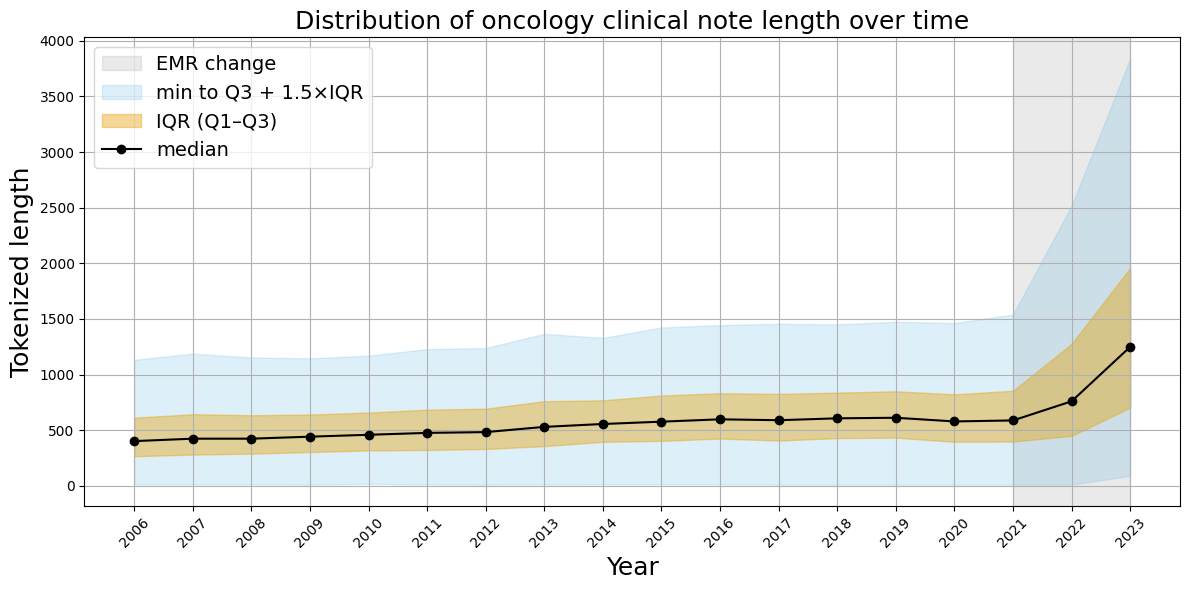

In [ ]:
save_path = '/Users/wayne/Desktop/Cluster/WorkDirHome/gitrepo/2024/OncoTRAIL/paper/pmh_method/results/plots/schema'
fig, ax = plot_note_length_over_time(df_token_lengths)
fig.savefig(f"{save_path}/clinical_note_tokenized_length_over_time.png", dpi=300)